### Load libraries and data

In [36]:
import pandas as pd
import numpy as np
import warnings
import geopandas as gpd

warnings.filterwarnings('ignore')

In [37]:
url1 = "https://raw.githubusercontent.com/statzenthusiast921/wildfires/refs/heads/main/data/fire_df_wa.csv"
url2 = "https://raw.githubusercontent.com/statzenthusiast921/wildfires/refs/heads/main/data/fire_df_or.csv"
url3 = "https://raw.githubusercontent.com/statzenthusiast921/wildfires/refs/heads/main/data/fire_df_ca.csv"

df_wa = pd.read_csv(url1)
df_or = pd.read_csv(url2)
df_ca = pd.read_csv(url3, dtype={16: str, 18: str})

In [38]:
df = pd.concat([df_wa, df_or, df_ca], ignore_index=True)
df.shape

(284151, 19)

### Clean up data

In [39]:
df['EndDate'] = pd.to_datetime(df['CONT_DATE'], unit='D', origin='julian')
df['StartDate'] = pd.to_datetime(df['DISCOVERY_DATE'], unit='D', origin='julian')
df['FireLengthDays'] = df['CONT_DATE'] - df['DISCOVERY_DATE']

In [40]:
df.head()

,NWCG_REPORTING_UNIT_NAME,FIRE_NAME,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,STAT_CAUSE_CODE,STAT_CAUSE_DESCR,CONT_DATE,CONT_DOY,...,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,STATE,COUNTY,FIPS_CODE,FIPS_NAME,EndDate,StartDate,FireLengthDays
0,Umatilla National Forest,UPPER JIM,2005,2453540.5,170,1430.0,1.0,Lightning,2453541.5,171.0,...,B,46.220833,-117.785000,WA,27,27.0,Grays Harbor,2005-06-20,2005-06-19,1.0
1,Umatilla National Forest,SKYLINE,2005,2453567.5,197,1354.0,4.0,Campfire,2453567.5,197.0,...,A,46.080556,-117.890833,WA,13,13.0,Columbia,2005-07-16,2005-07-16,0.0
2,Columbia River Gorge National Scenic Area,MP 80,2005,2453516.5,146,950.0,6.0,Railroad,2453516.5,146.0,...,A,45.665000,-121.203611,WA,39,39.0,Klickitat,2005-05-26,2005-05-26,0.0
3,Idaho Panhandle National Forest,BUTCH CREEK,2005,2453585.5,215,1236.0,9.0,Miscellaneous,2453585.5,215.0,...,A,48.356667,-117.060833,WA,51,51.0,Pend Oreille,2005-08-03,2005-08-03,0.0
4,Columbia River Gorge National Scenic Area,LOCKE LAKE,2005,2453555.5,185,2002.0,6.0,Railroad,2453555.5,185.0,...,A,45.699444,-121.413611,WA,39,39.0,Klickitat,2005-07-04,2005-07-04,0.0


In [41]:
prefix_map = {"WA": "53", "CA": "06", "OR": "41"}

def make_fips(row):
    if pd.isna(row["FIPS_CODE"]):
        return np.nan
    
    county_code = str(int(row["FIPS_CODE"])).zfill(3)
    state_prefix = prefix_map.get(row["STATE"], "")
    
    return state_prefix + county_code if state_prefix else np.nan

df["FIPS"] = df.apply(make_fips, axis=1)

In [42]:
df["FIPS_length"] = df["FIPS"].astype(str).str.len()
df["FIPS_length"].value_counts()

FIPS_length
3    164516
5    119635
Name: count, dtype: int64

In [43]:
df_good = df[df['FIPS_length']==5]
df_bad = df[df['FIPS_length']==3]

### Get the FIPS code by using the lat/long coords

In [44]:
from shapely.geometry import Point
counties = gpd.read_file("/Users/jonzimmerman/Desktop/Data Projects/Wildfires/data/cb_2018_us_county_500k/cb_2018_us_county_500k.shp")
counties = counties[counties['STATEFP'].isin(['06','41','53'])]  # CA=06, OR=41, WA=53
counties = counties[['STATEFP', 'COUNTYFP', 'GEOID', 'geometry']]  # GEOID is full FIPS

# 2. Convert your df to a GeoDataFrame
gdf = gpd.GeoDataFrame(
    df_bad,
    geometry=gpd.points_from_xy(df_bad["LONGITUDE"], df_bad["LATITUDE"]),
    crs="EPSG:4326"
)

# 3. Spatial join
gdf = gpd.sjoin(gdf, counties, how="left", predicate="within")

# 4. Fill missing FIPS with GEOID from join
gdf["FIPS"] = gdf["FIPS"].fillna(gdf["GEOID"])

# 5. Drop geometry columns if you want back a regular DataFrame
df_bad = pd.DataFrame(gdf.drop(columns=['geometry', 'index_right', 'STATEFP', 'COUNTYFP', 'GEOID']))


In [45]:
df_all = pd.concat([df_bad, df_good], ignore_index=True)

In [46]:
#Recalculate
df_all["FIPS_length"] = df_all["FIPS"].astype(str).str.len()
df_all["FIPS_length"].value_counts()

FIPS_length
5    283906
3       245
Name: count, dtype: int64

In [47]:
df_all = df_all[df_all['FIPS_length']==5]

In [48]:
df_all.groupby("STATE")["FIPS"].nunique().reset_index()

,STATE,FIPS
0,CA,60
1,OR,41
2,WA,43


### Let's do count of fires by day - might be more fruitful

In [49]:
df_model = df_all[['FIPS','StartDate','STAT_CAUSE_DESCR','FIRE_SIZE','FireLengthDays']]
df_model.head()

,FIPS,StartDate,STAT_CAUSE_DESCR,FIRE_SIZE,FireLengthDays
0,53059,2006-06-17,Miscellaneous,0.1,0.0
1,53051,1992-06-04,Lightning,0.1,0.0
2,53051,1992-06-26,Lightning,0.1,0.0
3,53051,1992-06-26,Lightning,0.1,0.0
4,53051,1992-06-26,Lightning,0.1,0.0


In [50]:
df_model['StartDate'].max()

Timestamp('2015-12-31 00:00:00')

### Count fires by cause and date

In [51]:
counts = (
    df_model
    .groupby(['FIPS', 'StartDate', 'STAT_CAUSE_DESCR'])
    .size()
    .reset_index(name='FireCount')
)

In [52]:
pivoted = counts.pivot_table(
    index=['FIPS', 'StartDate'],
    columns='STAT_CAUSE_DESCR',
    values='FireCount',
    fill_value=0
).reset_index()

### Impute days without fires with values = 0

In [53]:
df_model['StartDate'] = pd.to_datetime(df_model['StartDate'])
max_date_for_all_fips = pd.Timestamp('2015-12-31')

out = []
for fips, g in pivoted.groupby('FIPS'):
    # full date range for this FIPS
    idx = pd.date_range(g['StartDate'].min(), max_date_for_all_fips, freq='D')
    g = g.set_index('StartDate').reindex(idx, fill_value=0)
    g['FIPS'] = fips
    g = g.rename_axis('StartDate').reset_index()
    g.columns.name = None
    out.append(g)

full = pd.concat(out, ignore_index=True)
full.columns.name = None

### Change counts by cause to %s

In [54]:
cause_cols = [c for c in full.columns if c not in ['FIPS','StartDate']]

# total fire count per row
full['TotalFires'] = full[cause_cols].sum(axis=1)

# percentage columns
for c in cause_cols:
    full[f'{c}_pct'] = full[c] / full['TotalFires'].replace(0, 1) 

### Consolidate columns

In [55]:
cols_to_keep = ['StartDate', 'FIPS', 'TotalFires'] + [col for col in full.columns if col.endswith('_pct')]
full = full[cols_to_keep]

### ZIPS on FIPS

In [104]:
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.discrete.count_model import ZeroInflatedPoisson
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

#-----Define train/test split per FIPS
def split_train_test(df, test_days=365):
    df = df.sort_values('StartDate')
    train = df.iloc[:-test_days] if len(df) > test_days else df
    test = df.iloc[-test_days:] if len(df) > test_days else pd.DataFrame()
    return train, test

train_test_splits = {}
for fips, group in full.groupby('FIPS'):
    train, test = split_train_test(group)
    train_test_splits[fips] = {'train': train, 'test': test}

### Fit ZIP per FIPS (train only)

In [105]:
models = {}
for fips, splits in train_test_splits.items():
    train = splits['train']
    if len(train) < 10:
        continue
    
    exog = sm.add_constant(train[[col for col in train.columns if col.endswith('_pct')]])
    exog_infl = exog.copy()
    model = sm.ZeroInflatedPoisson(train['TotalFires'], exog, exog_infl=exog_infl).fit(disp=0)
    models[fips] = model

### Calibrate using test data

In [106]:
calibration_results = []
for fips, splits in train_test_splits.items():
    if fips not in models:
        continue
    train = splits['train']
    test = splits['test']
    if test.empty:
        continue
    
    model = models[fips]
    exog_test = sm.add_constant(test[[col for col in test.columns if col.endswith('_pct')]])
    exog_test = exog_test.reindex(columns=['const'] + [col for col in test.columns if col.endswith('_pct')], fill_value=0)
    exog_infl_test = exog_test.copy()
    
    test = test.copy()
    test['PredictedFires'] = model.predict(exog=exog_test, exog_infl=exog_infl_test)
    
    rmse = np.sqrt(mean_squared_error(test['TotalFires'], test['PredictedFires']))
    mae = mean_absolute_error(test['TotalFires'], test['PredictedFires'])
    calibration_results.append({'FIPS': fips, 'RMSE': rmse, 'MAE': mae})

calibration_df = pd.DataFrame(calibration_results)

### Refit on full data

In [108]:
final_models = {}
for fips, group in full.groupby('FIPS'):
    if len(group) < 10:
        continue
    exog = sm.add_constant(group[[col for col in group.columns if col.endswith('_pct')]])
    exog_infl = exog.copy()
    model = sm.ZeroInflatedPoisson(group['TotalFires'], exog, exog_infl=exog_infl).fit(disp=0)
    final_models[fips] = model

### Seasonal Weighted Forecasts

In [117]:
from datetime import timedelta

forecast_horizon = 365
future_forecasts = []

for fips, model in final_models.items():
    df_fips = full[full['FIPS'] == fips].copy()
    
    # Drop rows with missing dates
    df_fips = df_fips[df_fips['StartDate'].notna()]
    if df_fips.empty:
        continue
    
    df_fips['DOY'] = df_fips['StartDate'].dt.dayofyear
    cause_cols = [c for c in df_fips.columns if c.endswith('_pct')]
    
    # Seasonal weights: more weight for recent years
    decay = 0.8
    years = df_fips['StartDate'].dt.year
    max_year = years.max()
    weights = decay ** (max_year - years)
    
    # Compute weighted average percentages per DOY
    weighted_list = []
    for doy, group in df_fips.groupby('DOY'):
        w = weights.loc[group.index]
        avg = np.average(group[cause_cols], axis=0, weights=w)
        weighted_list.append([doy] + list(avg))
    
    seasonal_pct = pd.DataFrame(weighted_list, columns=['DOY'] + cause_cols)
    
    # Build future dates
    last_date = df_fips['StartDate'].max()
    future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=forecast_horizon)
    
    # Build future exogenous features
    future_exog_rows = []
    for date in future_dates:
        doy = date.timetuple().tm_yday
        if doy in seasonal_pct['DOY'].values:
            row = seasonal_pct.loc[seasonal_pct['DOY'] == doy, cause_cols].iloc[0]
        else:
            # fallback to overall mean if DOY not present (e.g., leap year)
            row = seasonal_pct[cause_cols].mean()
        future_exog_rows.append(row)
    
    future_exog = pd.DataFrame(future_exog_rows).reset_index(drop=True)
    future_exog = sm.add_constant(future_exog)
    future_exog_infl = future_exog.copy()
    
    # Predict future fires
    preds = model.predict(exog=future_exog, exog_infl=future_exog_infl)
    
    future_forecasts.append(pd.DataFrame({
        'FIPS': fips,
        'StartDate': future_dates,
        'PredictedFires': preds,
        'Key': 'Forecast'
    }))

forecast_df = pd.concat(future_forecasts, ignore_index=True)

### Combine actuals and predictions

In [119]:
actuals = full[['FIPS','StartDate','TotalFires']].copy()
actuals.rename(columns={'TotalFires':'PredictedFires'}, inplace=True)
actuals['Key'] = 'Actual'

combined_df = pd.concat([actuals, forecast_df], ignore_index=True)

In [121]:
combined_df.tail()

,FIPS,StartDate,PredictedFires,Key
1203162,53077,2016-12-26,0.009375,Forecast
1203163,53077,2016-12-27,0.009375,Forecast
1203164,53077,2016-12-28,0.009433,Forecast
1203165,53077,2016-12-29,0.009375,Forecast
1203166,53077,2016-12-30,0.009375,Forecast


### Example plots

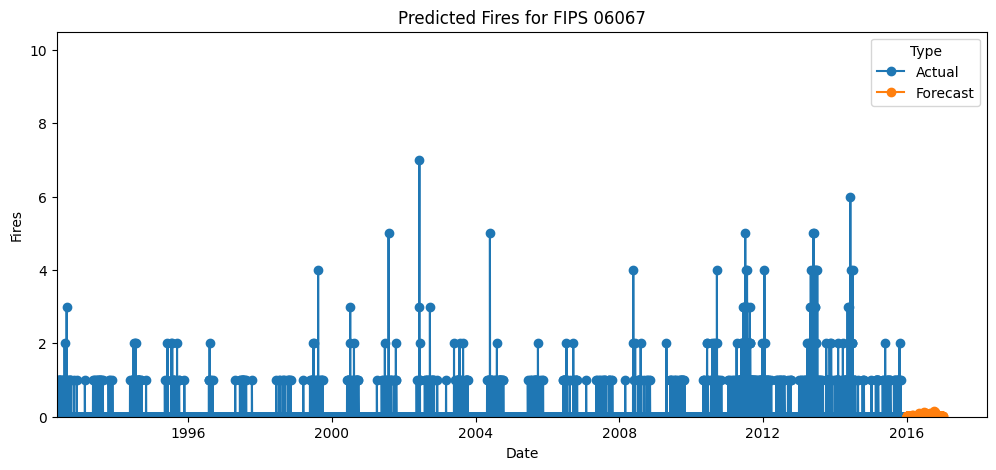

In [125]:
fips_code = '06067'
df_plot = combined_df[combined_df['FIPS'] == fips_code].sort_values('StartDate')

plt.figure(figsize=(12, 5))
for key, group in df_plot.groupby('Key'):
    plt.plot(group['StartDate'], group['PredictedFires'], label=key, marker='o')

plt.title(f'Predicted Fires for FIPS {fips_code}')
plt.xlabel('Date')
plt.ylabel('Fires')
plt.xlim(left=df_plot['StartDate'].min())
plt.ylim(0, max(df_plot['PredictedFires'].max()*1.5, 0.01))
plt.legend(title='Type')
plt.show()